<a href="https://colab.research.google.com/github/SHREYASHSHAURYA/ML-6th-Sem-Lab/blob/main/k_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Step 1: Load the Dataset

I will load the 'Wholesale customers data set' from a CSV file. This dataset includes annual spending by clients of a wholesale distributor on different product categories, which is suitable for clustering clients into segments.

In [ ]:
import pandas as pd
import requests
import io

# URL for the Wholesale Customers dataset CSV
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv"

# Download the CSV content
try:
    response = requests.get(url)
    response.raise_for_status() # Raise an exception for HTTP errors
    csv_content = response.text

    # Load the data into a pandas DataFrame. The dataset has a header.
    df = pd.read_csv(io.StringIO(csv_content))

    print("Wholesale Customers dataset loaded successfully.")
    display(df.head())
    display(df.info())
except requests.exceptions.RequestException as e:
    print(f"Error downloading the dataset: {e}")
except Exception as e:
    print(f"An error occurred: {e}")

Wholesale Customers dataset loaded successfully.


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


None

### Step 2: Preprocess the Data

k-Means algorithm is sensitive to the scale of the features. Therefore, it's a good practice to scale the data before applying the algorithm. For the Wholesale Customers dataset, 'Channel' and 'Region' are categorical identifiers and should be handled separately or dropped for basic clustering of spending habits. For this example, we will drop them and focus on scaling the numerical spending features.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Drop 'Channel' and 'Region' as they are categorical identifiers for this clustering example
X_features = df.drop(columns=['Channel', 'Region'])

# Scale the features
scaler = StandardScaler() # Corrected typo: changed 'serr' to 'scaler'
X_scaled = scaler.fit_transform(X_features)

print("Data scaled successfully. Here are the first 5 rows of scaled data:")
display(pd.DataFrame(X_scaled, columns=X_features.columns).head())

Data scaled successfully. Here are the first 5 rows of scaled data:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339
1,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151
2,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293
3,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411
4,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347


### Step 3: Determine the Optimal Number of Clusters (Elbow Method)

The Elbow method helps to find the optimal number of clusters (`k`) for k-Means clustering. It involves plotting the Within-Cluster Sum of Squares (WCSS) against the number of clusters and choosing the 'elbow' point where the decrease in WCSS begins to level off.

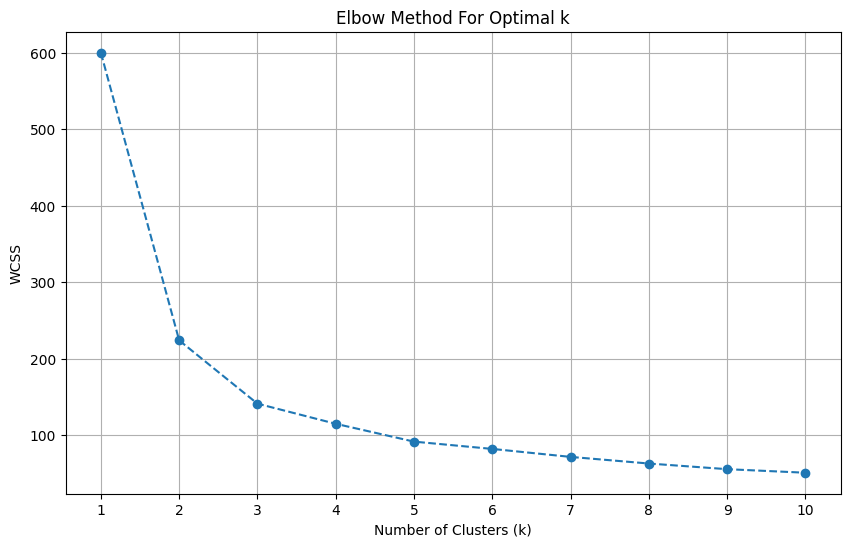

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

wcss = []
max_k = 10 # You can adjust this based on your data

for i in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.xticks(range(1, max_k + 1))
plt.grid(True)
plt.show()

Based on the elbow plot, you can observe where the decrease in WCSS starts to slow down significantly. For this dataset, an appropriate `k` value will be chosen from the elbow plot to proceed with k-Means clustering.

In [ ]:
# @title step_artifacts
num_fig = "1" # @param {type:"string"}
step = 'ModelDevelopment'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}

# Assuming `plt` is the last generated plot from the Elbow Method
# If you save the figure to a variable, use that variable instead of plt
# For example: fig.savefig('elbow_method.png')
# upload_plt_to_gcs(num_fig, step, plt.gcf())

### Step 4: Apply k-Means Clustering

Now, we will apply the k-Means algorithm with the chosen optimal number of clusters.

In [ ]:
# Choose the optimal number of clusters (e.g., 3 or 4 based on Elbow plot for Wholesale dataset)
k_optimal = 3 # @param {type:"integer"}

kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add the cluster labels to our original DataFrame
df['cluster'] = clusters

print(f"k-Means clustering applied with {k_optimal} clusters.")
display(df.head())

k-Means clustering applied with 3 clusters.


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,cluster
0,2,3,12669,9656,7561,214,2674,1338,1
1,2,3,7057,9810,9568,1762,3293,1776,1
2,2,3,6353,8808,7684,2405,3516,7844,1
3,1,3,13265,1196,4221,6404,507,1788,1
4,2,3,22615,5410,7198,3915,1777,5185,1


### Step 5: Visualize the Clusters

The Wholesale Customers dataset has more than 2 features, so we will use Principal Component Analysis (PCA) to reduce the dimensionality to 2 components for visualization. This allows us to plot the clusters in a 2D scatter plot.

Length of X_pca: 440
Length of df['cluster']: 440


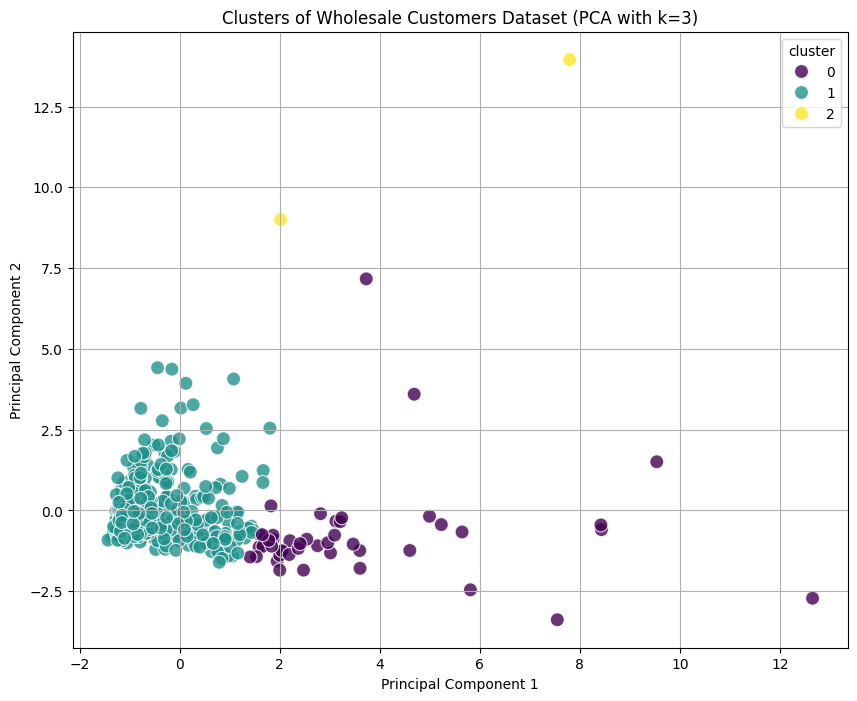

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import pandas as pd # Ensure pandas is imported if not already in scope

# Apply PCA to reduce dimensions to 2 for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for PCA results
pca_df = pd.DataFrame(data=X_pca, columns=['principal_component_1', 'principal_component_2'])

# Get the latest cluster assignments from the 'df' DataFrame
pca_df['cluster'] = df['cluster'] # Corrected: Use df['cluster'] instead of the global 'clusters' variable

# Diagnostic prints
print(f"Length of X_pca: {len(X_pca)}")
print(f"Length of df['cluster']: {len(df['cluster'])}")

# Visualize the clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(x='principal_component_1', y='principal_component_2', hue='cluster', data=pca_df,
                palette='viridis', s=100, alpha=0.8, legend='full')
plt.title(f'Clusters of Wholesale Customers Dataset (PCA with k={k_optimal})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

In [ ]:
# @title step_artifacts
num_fig = "2" # @param {type:"string"}
step = 'DataVisualization'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}

# This step now saves only one plot.
# upload_plt_to_gcs(num_fig, step, plt.gcf())